<a href="https://colab.research.google.com/github/nithyamurali12345/Clinical-trail/blob/main/GenAI_Week8code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (500, 8, 8, 1)


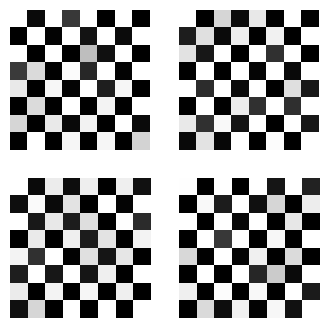

In [1]:
# Imports + Create synthetic dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

# Create a simple synthetic dataset: small 8x8 checkerboard images
def make_checkerboard(n_samples=500, size=8):
    images = []
    for _ in range(n_samples):
        img = np.zeros((size, size), dtype=np.float32)
        for i in range(size):
            for j in range(size):
                if (i + j) % 2 == 0:
                    img[i, j] = 1.0
        # optional noise
        img += np.random.normal(0, 0.1, (size, size))
        img = np.clip(img, 0, 1)
        images.append(img)
    images = np.array(images)
    return images[..., np.newaxis]  # add channel dimension

real_images = make_checkerboard(500, 8)
print("Dataset shape:", real_images.shape)

# Visualize a few images
plt.figure(figsize=(4,4))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(real_images[i,:,:,0], cmap='gray')
    plt.axis('off')
plt.show()


In [2]:
# Build simple DCGAN generator and discriminator

latent_dim = 16

# Generator: latent vector -> 8x8 image
generator = Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(8*8, activation='sigmoid'),
    layers.Reshape((8,8,1))
])

# Discriminator: 8x8 image -> real/fake
discriminator = Sequential([
    layers.Input(shape=(8,8,1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = tf.keras.losses.BinaryCrossentropy()
g_opt = tf.keras.optimizers.Adam(0.001)
d_opt = tf.keras.optimizers.Adam(0.001)

generator.summary()
discriminator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 1)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,816 (26.62 KB)

 Trainable params: 6,816 (26.62 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Training loop (short iterations for demonstration)

batch_size = 32
steps = 1000  # small number for demo
real_labels = tf.ones((batch_size,1))
fake_labels = tf.zeros((batch_size,1))

dataset = tf.data.Dataset.from_tensor_slices(real_images)
dataset = dataset.shuffle(500).batch(batch_size, drop_remainder=True).repeat()
data_iter = iter(dataset)

for step in range(1, steps+1):
    # Get a batch of real images
    real_batch = next(data_iter)

    # Train Discriminator
    z = tf.random.normal((batch_size, latent_dim))
    fake_batch = generator(z)

    with tf.GradientTape() as tape:
        real_pred = discriminator(real_batch)
        fake_pred = discriminator(fake_batch)
        d_loss = loss_fn(real_labels, real_pred) + loss_fn(fake_labels, fake_pred)
    grads = tape.gradient(d_loss, discriminator.trainable_weights)
    d_opt.apply_gradients(zip(grads, discriminator.trainable_weights))

    # Train Generator
    z = tf.random.normal((batch_size, latent_dim))
    with tf.GradientTape() as tape:
        fake_batch = generator(z)
        pred = discriminator(fake_batch)
        g_loss = loss_fn(real_labels, pred)
    grads = tape.gradient(g_loss, generator.trainable_weights)
    g_opt.apply_gradients(zip(grads, generator.trainable_weights))

    if step % 200 == 0:
        print(f"Step {step}/{steps} | D Loss: {d_loss.numpy():.4f} | G Loss: {g_loss.numpy():.4f}")


Step 200/1000 | D Loss: 0.4573 | G Loss: 1.9437
Step 400/1000 | D Loss: 0.1347 | G Loss: 3.3862
Step 600/1000 | D Loss: 0.2567 | G Loss: 2.8223
Step 800/1000 | D Loss: 0.0242 | G Loss: 4.3002
Step 1000/1000 | D Loss: 0.5833 | G Loss: 2.0697


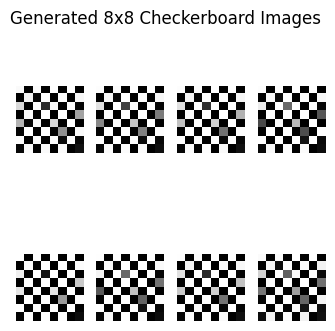

In [4]:
# Generate and display images

# Generate 8 new images

z = tf.random.normal((8, latent_dim))
gen_images = generator(z).numpy()

plt.figure(figsize=(4,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(gen_images[i,:,:,0], cmap='gray')
    plt.axis('off')
plt.suptitle("Generated 8x8 Checkerboard Images")
plt.show()
